# Onshore wind NPV simulation

Run the onshore wind electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_wind_onshore_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_wind_onshore_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,wind_onshore,1000000.0,2500.0,400.0,400000.0,1661.971226,35.970034,7.320756,0.0,...,94070000.0,1.438801e+07,7.320756e+06,0.0,0.0,7.236123e+07,1.076514e+08,25000000.0,4.306058,0.000004
1,1,wind_onshore,1000000.0,2500.0,400.0,400000.0,1421.262267,32.987625,7.578942,0.0,...,94070000.0,1.319505e+07,7.578942e+06,0.0,0.0,7.329601e+07,2.139136e+08,25000000.0,8.556543,0.000009
2,2,wind_onshore,1000000.0,2500.0,400.0,400000.0,1634.310328,38.687356,7.537000,0.0,...,94070000.0,1.547494e+07,7.537000e+06,0.0,0.0,7.105806e+07,1.048047e+08,25000000.0,4.192189,0.000004
3,3,wind_onshore,1000000.0,2500.0,400.0,400000.0,1427.177930,28.622831,5.714786,0.0,...,94070000.0,1.144913e+07,5.714786e+06,0.0,0.0,7.690608e+07,2.500840e+08,25000000.0,10.003361,0.000010
4,4,wind_onshore,1000000.0,2500.0,400.0,400000.0,1405.429891,36.255960,7.601605,0.0,...,94070000.0,1.450238e+07,7.601605e+06,0.0,0.0,7.196601e+07,2.060491e+08,25000000.0,8.241964,0.000008


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1.000000e+06
mean,145.762758,5.830510,5.830510e-06
std,71.088890,2.843556,2.843556e-06
min,-22.504926,-0.900197,-9.001970e-07
5%,35.005773,1.400231,1.400231e-06
50%,145.761969,5.830479,5.830479e-06
95%,256.748686,10.269947,1.026995e-05
max,308.646347,12.345854,1.234585e-05


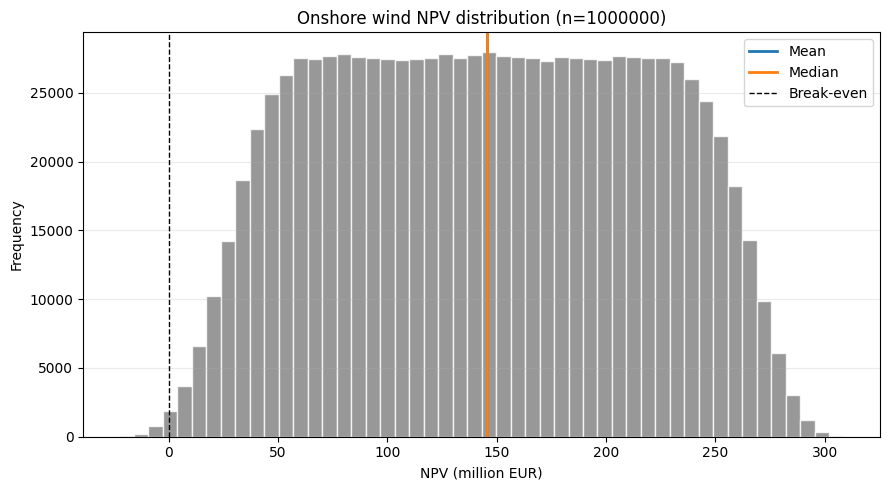

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Onshore wind NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


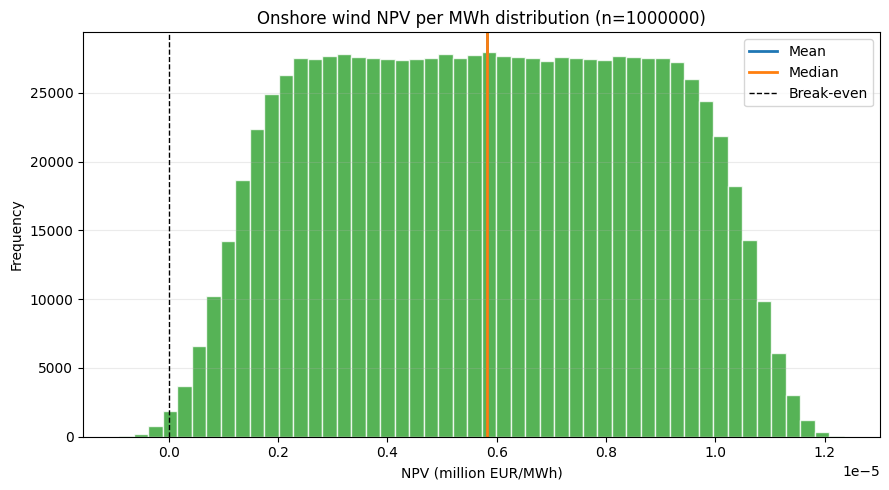

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Onshore wind NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        13.230018
annual_variable_opex_eur      7.233295
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     73.606687
Name: Mean annual value, million EUR, dtype: float64